# Sachs Paper Plots and Tables

This notebook reads the pulled Sachs budget-grid benchmark outputs from the ENCO repo and generates paper-facing tables and figures.

Outputs are written to `refine-logs/generated_sachs/` in this paper repo.


In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

PAPER_ROOT = Path('/Users/yuenc2/Desktop/LLM_CD_neurips2026')
ENCO_ROOT = Path('/Users/yuenc2/Desktop/ENCO')
RUN_DIR = ENCO_ROOT / 'benchmark_runs' / 'sachs_budget_grid'
OUT_DIR = PAPER_ROOT / 'refine-logs' / 'generated_sachs'
OUT_DIR.mkdir(parents=True, exist_ok=True)

EVAL_CSV = RUN_DIR / 'evaluation_summary.csv'
AUDIT_CSV = RUN_DIR / 'contamination_audit.csv'

assert EVAL_CSV.exists(), EVAL_CSV
assert AUDIT_CSV.exists(), AUDIT_CSV

eval_df = pd.read_csv(EVAL_CSV).copy()
audit_df = pd.read_csv(AUDIT_CSV).copy()

# Keep paper terminology stable even if old artifacts still use summary_joint.
eval_df['prompt_style'] = eval_df['prompt_style'].replace({'summary_joint': 'summary'})
audit_df['prompt_style'] = audit_df['prompt_style'].replace({'summary_joint': 'summary'})

sns.set_theme(style='whitegrid', context='talk')
pd.set_option('display.max_columns', 200)
pd.set_option('display.width', 200)

system_order = [
    'gpt-5-mini',
    'CausalLLMPrompt',
    'PC',
    'GES',
    'ENCO',
    'JiralerspongBFS',
    'TakayamaSCP',
]

cell_order = [
    (0, 0, 'names_only', 'names_only'),
    (1000, 0, 'summary', 'anonymized'),
    (1000, 0, 'summary', 'real'),
    (1000, 50, 'matrix', 'real'),
    (1000, 50, 'summary', 'real'),
    (1000, 200, 'summary', 'real'),
    (5000, 0, 'summary', 'anonymized'),
    (5000, 0, 'summary', 'real'),
    (5000, 50, 'summary', 'real'),
    (5000, 200, 'matrix', 'real'),
    (5000, 200, 'summary', 'real'),
]

def make_cell_label(row: pd.Series) -> str:
    return f"({int(row['obs_n'])},{int(row['int_n'])})\\n{row['prompt_style']}\\n{row['naming_regime']}"

eval_df['cell_label'] = eval_df.apply(make_cell_label, axis=1)
cell_label_order = [f'({obs},{int_n})\\n{style}\\n{name}' for obs, int_n, style, name in cell_order]

paper_df = eval_df[eval_df['system'].isin(system_order)].copy()
paper_df['system'] = pd.Categorical(paper_df['system'], categories=system_order, ordered=True)
paper_df['cell_label'] = pd.Categorical(paper_df['cell_label'], categories=cell_label_order, ordered=True)


In [2]:
overview_cols = [
    'system', 'system_kind', 'prompt_style', 'naming_regime',
    'obs_n', 'int_n', 'avg_f1', 'avg_shd', 'consensus_f1', 'consensus_shd'
]
overview = paper_df[overview_cols].sort_values(['obs_n', 'int_n', 'prompt_style', 'naming_regime', 'system'])
display(overview)
overview.to_csv(OUT_DIR / 'sachs_main_results_long.csv', index=False)
print('Wrote', OUT_DIR / 'sachs_main_results_long.csv')


,system,system_kind,prompt_style,naming_regime,obs_n,int_n,avg_f1,avg_shd,consensus_f1,consensus_shd
10,gpt-5-mini,model,names_only,names_only,0,0,0.496552,14.2,0.500000,14
19,CausalLLMPrompt,baseline,names_only,names_only,0,0,0.416667,14.0,0.416667,14
1,gpt-5-mini,model,summary,anonymized,1000,0,0.517135,13.2,0.347826,15
11,PC,baseline,summary,anonymized,1000,0,0.333333,20.0,0.333333,20
13,GES,baseline,summary,anonymized,1000,0,0.487805,21.0,0.487805,21
0,gpt-5-mini,model,summary,real,1000,0,0.506623,14.6,0.480000,13
20,JiralerspongBFS,baseline,summary,real,1000,0,0.400000,15.0,0.400000,15
22,TakayamaSCP,baseline,summary,real,1000,0,0.272727,16.0,0.272727,16
8,gpt-5-mini,model,matrix,real,1000,50,0.404488,16.4,0.428571,16
15,ENCO,baseline,matrix,real,1000,50,1.000000,0.0,1.000000,0


Wrote /Users/yuenc2/Desktop/LLM_CD_neurips2026/refine-logs/generated_sachs/sachs_main_results_long.csv


In [3]:
main_table = paper_df[
    [
        'system', 'system_kind', 'prompt_style', 'naming_regime',
        'obs_n', 'int_n', 'avg_f1', 'avg_shd', 'consensus_f1', 'consensus_shd'
    ]
].sort_values(['obs_n', 'int_n', 'prompt_style', 'naming_regime', 'system'])

main_table.to_csv(OUT_DIR / 'sachs_main_results_table.csv', index=False)
main_table.to_latex(
    OUT_DIR / 'sachs_main_results_table.tex',
    index=False,
    float_format=lambda x: f'{x:.3f}' if isinstance(x, float) else str(x),
)

display(main_table)
print('Wrote', OUT_DIR / 'sachs_main_results_table.csv')
print('Wrote', OUT_DIR / 'sachs_main_results_table.tex')


,system,system_kind,prompt_style,naming_regime,obs_n,int_n,avg_f1,avg_shd,consensus_f1,consensus_shd
10,gpt-5-mini,model,names_only,names_only,0,0,0.496552,14.2,0.500000,14
19,CausalLLMPrompt,baseline,names_only,names_only,0,0,0.416667,14.0,0.416667,14
1,gpt-5-mini,model,summary,anonymized,1000,0,0.517135,13.2,0.347826,15
11,PC,baseline,summary,anonymized,1000,0,0.333333,20.0,0.333333,20
13,GES,baseline,summary,anonymized,1000,0,0.487805,21.0,0.487805,21
0,gpt-5-mini,model,summary,real,1000,0,0.506623,14.6,0.480000,13
20,JiralerspongBFS,baseline,summary,real,1000,0,0.400000,15.0,0.400000,15
22,TakayamaSCP,baseline,summary,real,1000,0,0.272727,16.0,0.272727,16
8,gpt-5-mini,model,matrix,real,1000,50,0.404488,16.4,0.428571,16
15,ENCO,baseline,matrix,real,1000,50,1.000000,0.0,1.000000,0


Wrote /Users/yuenc2/Desktop/LLM_CD_neurips2026/refine-logs/generated_sachs/sachs_main_results_table.csv
Wrote /Users/yuenc2/Desktop/LLM_CD_neurips2026/refine-logs/generated_sachs/sachs_main_results_table.tex


In [4]:
compact = paper_df.copy()
compact['F1 / SHD'] = compact.apply(lambda r: f"{r['avg_f1']:.3f} / {r['avg_shd']:.1f}", axis=1)
compact_table = compact.pivot_table(
    index='system',
    columns='cell_label',
    values='F1 / SHD',
    aggfunc='first',
)
compact_table = compact_table.reindex(system_order)

display(compact_table)
compact_table.to_csv(OUT_DIR / 'sachs_main_compact_table.csv')
compact_table.to_latex(OUT_DIR / 'sachs_main_compact_table.tex', escape=False)
print('Wrote', OUT_DIR / 'sachs_main_compact_table.csv')
print('Wrote', OUT_DIR / 'sachs_main_compact_table.tex')


/var/folders/h3/mg_n_0ls7kgb1369wvkmb_dh0000gq/T/ipykernel_39073/2998926572.py:3: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  compact_table = compact.pivot_table(


cell_label,"(0,0)\nnames_only\nnames_only","(1000,0)\nsummary\nanonymized","(1000,0)\nsummary\nreal","(1000,50)\nmatrix\nreal","(1000,50)\nsummary\nreal","(1000,200)\nsummary\nreal","(5000,0)\nsummary\nanonymized","(5000,0)\nsummary\nreal","(5000,50)\nsummary\nreal","(5000,200)\nmatrix\nreal","(5000,200)\nsummary\nreal"
system,,,,,,,,,,,
gpt-5-mini,0.497 / 14.2,0.517 / 13.2,0.507 / 14.6,0.404 / 16.4,0.431 / 16.8,0.487 / 15.2,0.617 / 12.2,0.474 / 16.4,0.504 / 16.0,0.446 / 15.8,0.455 / 16.4
CausalLLMPrompt,0.417 / 14.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
PC,NaN,0.333 / 20.0,NaN,NaN,NaN,NaN,0.588 / 14.0,NaN,NaN,NaN,NaN
GES,NaN,0.488 / 21.0,NaN,NaN,NaN,NaN,0.667 / 17.0,NaN,NaN,NaN,NaN
ENCO,NaN,NaN,NaN,1.000 / 0.0,NaN,0.970 / 1.0,NaN,NaN,0.944 / 2.0,1.000 / 0.0,NaN
JiralerspongBFS,NaN,NaN,0.400 / 15.0,NaN,NaN,NaN,NaN,0.240 / 19.0,NaN,NaN,NaN
TakayamaSCP,NaN,NaN,0.273 / 16.0,NaN,NaN,NaN,NaN,0.188 / 26.0,NaN,NaN,NaN


Wrote /Users/yuenc2/Desktop/LLM_CD_neurips2026/refine-logs/generated_sachs/sachs_main_compact_table.csv
Wrote /Users/yuenc2/Desktop/LLM_CD_neurips2026/refine-logs/generated_sachs/sachs_main_compact_table.tex


In [5]:
naming_table = audit_df.sort_values(['obs_n', 'int_n', 'prompt_style', 'model']).copy()
display(naming_table)
naming_table.to_csv(OUT_DIR / 'sachs_naming_audit.csv', index=False)
naming_table.to_latex(
    OUT_DIR / 'sachs_naming_audit.tex',
    index=False,
    float_format=lambda x: f'{x:.3f}' if isinstance(x, float) else str(x),
)
print('Wrote', OUT_DIR / 'sachs_naming_audit.csv')
print('Wrote', OUT_DIR / 'sachs_naming_audit.tex')


,dataset,prompt_style,model,obs_n,int_n,real_f1,anonymized_f1,names_only_f1,real_minus_anonymized,real_minus_names_only,anonymized_minus_names_only
3,sachs,names_only,gpt-5-mini,0,0,NaN,NaN,0.500000,NaN,NaN,NaN
2,sachs,names_only,NaN,0,0,NaN,NaN,0.416667,NaN,NaN,NaN
6,sachs,summary,gpt-5-mini,1000,0,0.480000,0.347826,NaN,0.132174,NaN,NaN
4,sachs,summary,NaN,1000,0,0.272727,NaN,NaN,NaN,NaN,NaN
0,sachs,matrix,gpt-5-mini,1000,50,0.428571,NaN,NaN,NaN,NaN,NaN
7,sachs,summary,gpt-5-mini,1000,50,0.384615,NaN,NaN,NaN,NaN,NaN
8,sachs,summary,gpt-5-mini,1000,200,0.416667,NaN,NaN,NaN,NaN,NaN
9,sachs,summary,gpt-5-mini,5000,0,0.400000,0.600000,NaN,-0.200000,NaN,NaN
5,sachs,summary,NaN,5000,0,0.187500,NaN,NaN,NaN,NaN,NaN
10,sachs,summary,gpt-5-mini,5000,50,0.434783,NaN,NaN,NaN,NaN,NaN


Wrote /Users/yuenc2/Desktop/LLM_CD_neurips2026/refine-logs/generated_sachs/sachs_naming_audit.csv
Wrote /Users/yuenc2/Desktop/LLM_CD_neurips2026/refine-logs/generated_sachs/sachs_naming_audit.tex


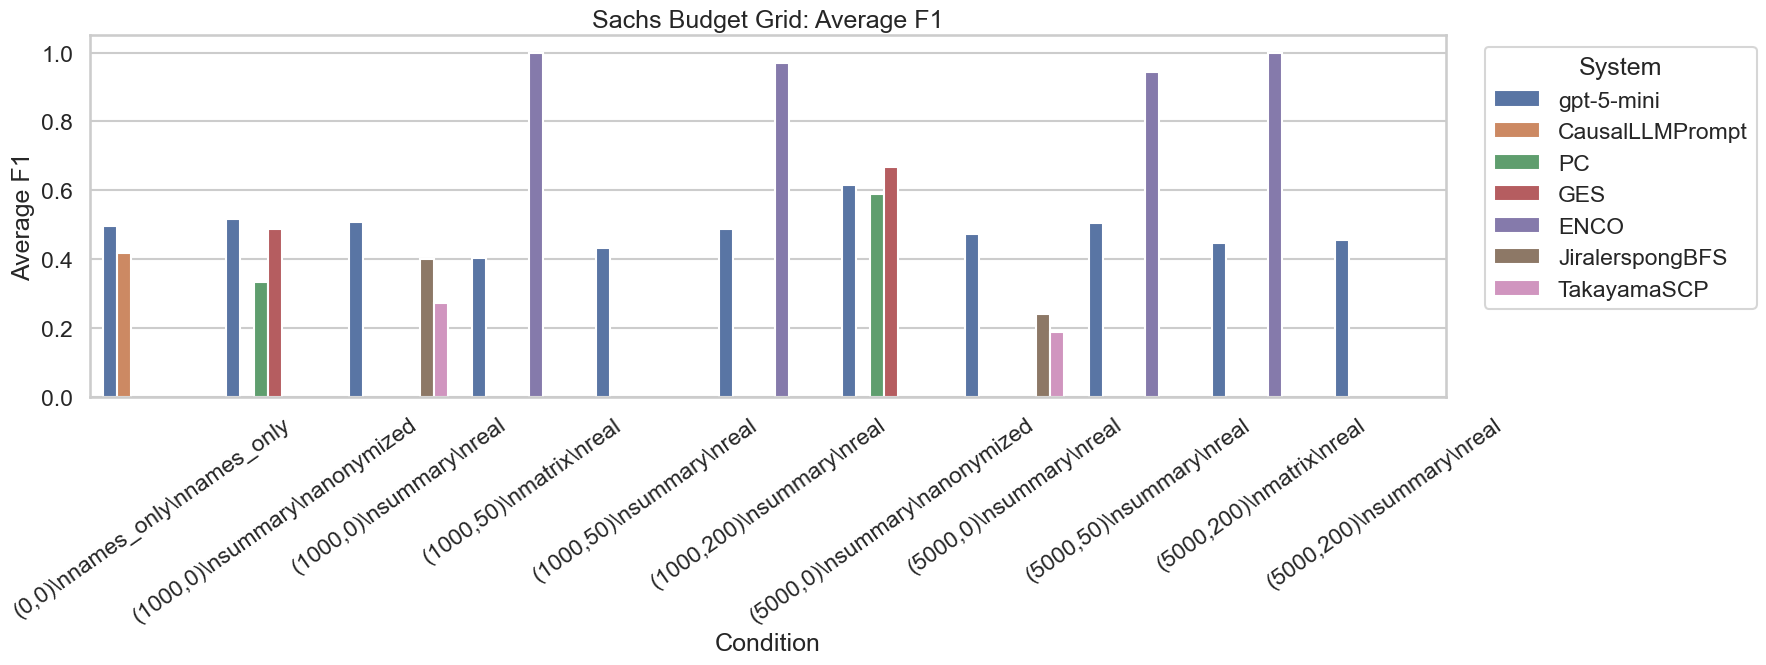

Wrote /Users/yuenc2/Desktop/LLM_CD_neurips2026/refine-logs/generated_sachs/sachs_budget_grid_avg_f1.pdf
Wrote /Users/yuenc2/Desktop/LLM_CD_neurips2026/refine-logs/generated_sachs/sachs_budget_grid_avg_f1.png


In [6]:
fig, ax = plt.subplots(figsize=(18, 7))
sns.barplot(
    data=paper_df.sort_values(['cell_label', 'system']),
    x='cell_label',
    y='avg_f1',
    hue='system',
    hue_order=system_order,
    ax=ax,
)
ax.set_xlabel('Condition')
ax.set_ylabel('Average F1')
ax.set_title('Sachs Budget Grid: Average F1')
ax.tick_params(axis='x', rotation=35)
ax.legend(title='System', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(OUT_DIR / 'sachs_budget_grid_avg_f1.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'sachs_budget_grid_avg_f1.png', dpi=200, bbox_inches='tight')
plt.show()
print('Wrote', OUT_DIR / 'sachs_budget_grid_avg_f1.pdf')
print('Wrote', OUT_DIR / 'sachs_budget_grid_avg_f1.png')


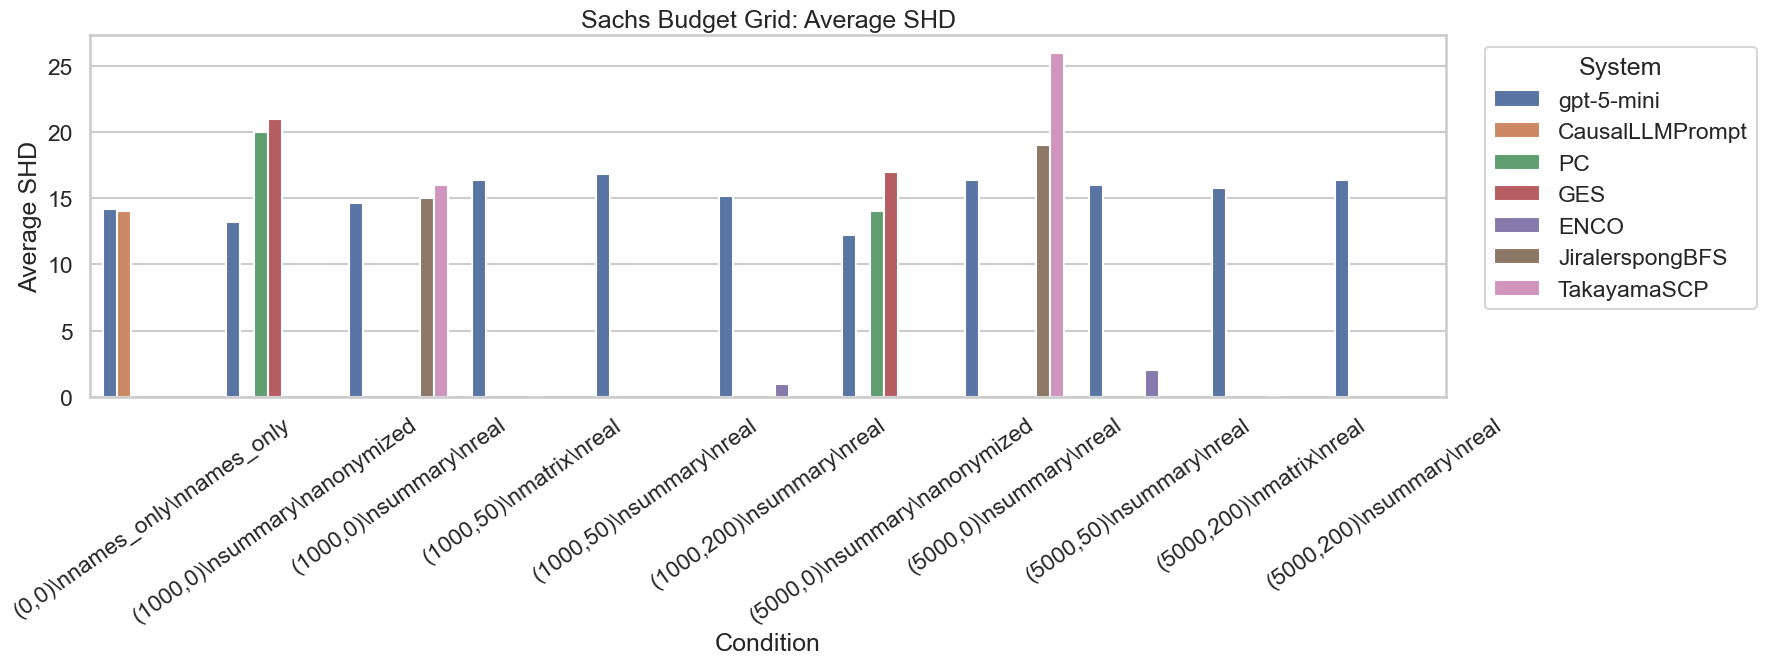

Wrote /Users/yuenc2/Desktop/LLM_CD_neurips2026/refine-logs/generated_sachs/sachs_budget_grid_avg_shd.pdf
Wrote /Users/yuenc2/Desktop/LLM_CD_neurips2026/refine-logs/generated_sachs/sachs_budget_grid_avg_shd.png


In [7]:
fig, ax = plt.subplots(figsize=(18, 7))
sns.barplot(
    data=paper_df.sort_values(['cell_label', 'system']),
    x='cell_label',
    y='avg_shd',
    hue='system',
    hue_order=system_order,
    ax=ax,
)
ax.set_xlabel('Condition')
ax.set_ylabel('Average SHD')
ax.set_title('Sachs Budget Grid: Average SHD')
ax.tick_params(axis='x', rotation=35)
ax.legend(title='System', bbox_to_anchor=(1.02, 1), loc='upper left')
fig.tight_layout()
fig.savefig(OUT_DIR / 'sachs_budget_grid_avg_shd.pdf', bbox_inches='tight')
fig.savefig(OUT_DIR / 'sachs_budget_grid_avg_shd.png', dpi=200, bbox_inches='tight')
plt.show()
print('Wrote', OUT_DIR / 'sachs_budget_grid_avg_shd.pdf')
print('Wrote', OUT_DIR / 'sachs_budget_grid_avg_shd.png')


In [9]:
best_by_cell = (
    paper_df.sort_values(['cell_label', 'avg_f1'], ascending=[True, False])
    .groupby('cell_label', observed=True)
    .head(1)
    [[ 'cell_label', 'system', 'avg_f1', 'avg_shd' ]]
    .sort_values('cell_label')
)
display(best_by_cell)
best_by_cell.to_csv(OUT_DIR / 'sachs_best_by_cell.csv', index=False)
print('Wrote', OUT_DIR / 'sachs_best_by_cell.csv')


,cell_label,system,avg_f1,avg_shd
10,"(0,0)\nnames_only\nnames_only",gpt-5-mini,0.496552,14.2
1,"(1000,0)\nsummary\nanonymized",gpt-5-mini,0.517135,13.2
0,"(1000,0)\nsummary\nreal",gpt-5-mini,0.506623,14.6
15,"(1000,50)\nmatrix\nreal",ENCO,1.000000,0.0
4,"(1000,50)\nsummary\nreal",gpt-5-mini,0.431384,16.8
17,"(1000,200)\nsummary\nreal",ENCO,0.969697,1.0
14,"(5000,0)\nsummary\nanonymized",GES,0.666667,17.0
2,"(5000,0)\nsummary\nreal",gpt-5-mini,0.474007,16.4
18,"(5000,50)\nsummary\nreal",ENCO,0.944444,2.0
16,"(5000,200)\nmatrix\nreal",ENCO,1.000000,0.0


Wrote /Users/yuenc2/Desktop/LLM_CD_neurips2026/refine-logs/generated_sachs/sachs_best_by_cell.csv
